# End-to-End Hybrid Model: PhoBERT + SentiWordNet (Fine-tuned)

## Đặc điểm:
1. **Unfrozen PhoBERT** - Fine-tune PhoBERT cùng lúc với classifier
2. **Extended SentiWordNet Features** - 35 features thay vì 8 features
3. **SMOTE** - Xử lý class imbalance cho Neutral class
4. **Class Weights** - Weighted loss cho class imbalance
5. **Early Stopping** - Ngăn overfitting
6. **Warmup + Cosine Decay** - Learning rate scheduling

## Architecture:
```
Text → PhoBERT (768-dim, trainable) ─┐
                                      ├─→ Concat → Dropout → Linear → Softmax
Text → SentiWordNet (35 features) ───┘
```
Total: 803 features

## 1. Setup và Import Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers torch scikit-learn matplotlib seaborn tqdm

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import pickle
import json
from tqdm import tqdm
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

## 2. Configuration

In [5]:
class Config:
    BASE_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis'
    DATA_DIR = f'{BASE_DIR}/data/processed'

    # Results directory structure
    MODEL_TYPE = 'PhoBERT_Sentiwordnet'
    EXPERIMENT_TYPE = 'improvements'
    TIMESTAMP = '20260316'
    RESULTS_DIR = f'{BASE_DIR}/results/{MODEL_TYPE}/{EXPERIMENT_TYPE}/{TIMESTAMP}'

    # SentiWordNet
    SENTIWORDNET_FILE = f'{BASE_DIR}/data/sentiwordnet-dataset/VietSentiWordnet_Ver1.3.5.txt'

    # Model settings
    MODEL_NAME = 'vinai/phobert-base'
    MAX_LENGTH = 256
    BATCH_SIZE = 32
    NUM_CLASSES = 3
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Training settings
    LEARNING_RATE = 2e-5
    EPOCHS = 5
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    DROPOUT = 0.3
    EARLY_STOP_PATIENCE = 2
    GRADIENT_CLIP = 1.0

    # Class weights for imbalanced data
    CLASS_WEIGHTS = torch.tensor([1.0, 5.0, 1.0], dtype=torch.float)  # Higher weight for Neutral

    # Subdirectories
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')

config = Config()

# Create all subdirectories
for dir_path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR,
                 config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

print(f'Results will be saved to: {config.RESULTS_DIR}')
print(f'Device: {config.DEVICE}')
print(f'Learning Rate: {config.LEARNING_RATE}')
print(f'Epochs: {config.EPOCHS}')
print(f'Batch Size: {config.BATCH_SIZE}')

Results will be saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/improvements/20260316
Device: cuda
Learning Rate: 2e-05
Epochs: 5
Batch Size: 32


## 3. Load Data

In [6]:
# Import from centralized data_utils module
import sys
sys.path.append(config.BASE_DIR)
from src.data_utils import load_data

train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

print(f'Train: {len(train_texts)} samples')
print(f'Val: {len(val_texts)} samples')
print(f'Test: {len(test_texts)} samples')

Train: 11426 samples
Val: 1583 samples
Test: 3166 samples


In [7]:
print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}:')
    for label, count in sorted(counter.items()):
        print(f'  {config.LABEL_MAP[label]}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train:
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Val:
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test:
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. Load SentiWordNet & Extract Extended Features

In [8]:
from src.data_utils import (
    load_sentiwordnet,
    extract_swn_features_extended_batch,
    SWN_EXTENDED_FEATURE_NAMES
)

# Load SentiWordNet lexicon
print('Loading VietSentiWordNet lexicon...')
word_to_scores = load_sentiwordnet(config.SENTIWORDNET_FILE)
print(f'Loaded {len(word_to_scores)} words')

# Extract extended features (35 features)
print('\nExtracting Extended SentiWordNet features (35 features)...')
train_swn = extract_swn_features_extended_batch(train_texts, word_to_scores)
val_swn = extract_swn_features_extended_batch(val_texts, word_to_scores)
test_swn = extract_swn_features_extended_batch(test_texts, word_to_scores)

print(f'\nSentiWordNet features shape:')
print(f'  Train: {train_swn.shape}')
print(f'  Val: {val_swn.shape}')
print(f'  Test: {test_swn.shape}')

Loading VietSentiWordNet lexicon...
Loaded 1227 words

Extracting Extended SentiWordNet features (35 features)...

SentiWordNet features shape:
  Train: (11426, 35)
  Val: (1583, 35)
  Test: (3166, 35)


In [9]:
# Scale SentiWordNet features
swn_scaler = StandardScaler()
train_swn_scaled = swn_scaler.fit_transform(train_swn)
val_swn_scaled = swn_scaler.transform(val_swn)
test_swn_scaled = swn_scaler.transform(test_swn)

# Save scaler
with open(os.path.join(config.ARTIFACTS_DIR, 'swn_scaler.pkl'), 'wb') as f:
    pickle.dump(swn_scaler, f)
print('SentiWordNet scaler saved to artifacts/')

SentiWordNet scaler saved to artifacts/


## 5. Model Definition - Hybrid PhoBERT + SentiWordNet

In [10]:
class HybridDataset(Dataset):
    """Dataset that returns text + SentiWordNet features + labels"""
    def __init__(self, texts, swn_features, labels, tokenizer, max_length):
        self.texts = texts
        self.swn_features = swn_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'swn_features': torch.tensor(self.swn_features[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [11]:
class PhoBertSentiWordNetClassifier(nn.Module):
    """
    Hybrid model: PhoBERT (trainable) + SentiWordNet features

    Architecture:
    - PhoBERT: 768-dim embeddings (trainable)
    - SentiWordNet: 35 features
    - Concat: 768 + 35 = 803 features
    - Classifier: Linear layers with dropout
    """
    def __init__(self, model_name, num_classes, swn_dim=35, dropout=0.3):
        super(PhoBertSentiWordNetClassifier, self).__init__()

        # PhoBERT backbone (trainable)
        self.phobert = AutoModel.from_pretrained(model_name)
        phobert_hidden_size = self.phobert.config.hidden_size  # 768

        # SentiWordNet feature projection
        self.swn_projection = nn.Sequential(
            nn.Linear(swn_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Combined classifier
        combined_size = phobert_hidden_size + 64  # 768 + 64 = 832
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, swn_features):
        # PhoBERT forward pass
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token, shape: (batch, 768)

        # SentiWordNet projection
        swn_projected = self.swn_projection(swn_features)  # shape: (batch, 64)

        # Concatenate
        combined = torch.cat([pooled_output, swn_projected], dim=1)  # shape: (batch, 832)

        # Classification
        logits = self.classifier(combined)

        return logits

In [12]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
print(f'Tokenizer loaded: {config.MODEL_NAME}')

# Initialize model
model = PhoBertSentiWordNetClassifier(
    model_name=config.MODEL_NAME,
    num_classes=config.NUM_CLASSES,
    swn_dim=35,
    dropout=config.DROPOUT
)
model = model.to(config.DEVICE)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel initialized!')
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'\nPhoBERT is UNFROZEN (trainable)')

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: vinai/phobert-base


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model initialized!
Total parameters: 135,214,595
Trainable parameters: 135,214,595

PhoBERT is UNFROZEN (trainable)


## 6. Training Setup

In [13]:
# Create dataloaders
train_dataset = HybridDataset(train_texts, train_swn_scaled, train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = HybridDataset(val_texts, val_swn_scaled, val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = HybridDataset(test_texts, test_swn_scaled, test_labels, tokenizer, config.MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 358
Val batches: 50
Test batches: 99


In [14]:
# Loss function with class weights
class_weights = config.CLASS_WEIGHTS.to(config.DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer with weight decay (AdamW)
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Learning rate scheduler with warmup
total_steps = len(train_loader) * config.EPOCHS
warmup_steps = int(total_steps * config.WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total steps: {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'Class weights: {class_weights.tolist()}')

Total steps: 1790
Warmup steps: 179
Class weights: [1.0, 5.0, 1.0]


## 7. Training Loop

In [15]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device, gradient_clip=1.0):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(dataloader, desc='Training'):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        swn_features = batch['swn_features'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, swn_features)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            swn_features = batch['swn_features'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask, swn_features)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1, all_preds, all_labels

In [16]:
# Training loop with early stopping
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_val_f1 = 0
best_epoch = 0
patience_counter = 0

print('='*60)
print('STARTING TRAINING')
print('='*60)

for epoch in range(config.EPOCHS):
    print(f'\nEpoch {epoch+1}/{config.EPOCHS}')
    print('-' * 40)

    # Train
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, config.DEVICE, config.GRADIENT_CLIP
    )

    # Validate
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, config.DEVICE)

    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}')
    print(f'Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}')

    # Early stopping check
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        patience_counter = 0

        # Save best model
        torch.save(model.state_dict(), os.path.join(config.MODELS_DIR, 'best_model.pt'))
        print(f'\u2705 New best model saved! (F1: {best_val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'\u23f3 No improvement. Patience: {patience_counter}/{config.EARLY_STOP_PATIENCE}')

    # Early stopping
    if patience_counter >= config.EARLY_STOP_PATIENCE:
        print(f'\n\u23f9 Early stopping at epoch {epoch+1}')
        break

print('\n' + '='*60)
print('TRAINING COMPLETED')
print('='*60)
print(f'Best epoch: {best_epoch}')
print(f'Best validation F1: {best_val_f1:.4f}')

STARTING TRAINING

Epoch 1/5
----------------------------------------



Evaluating: 100%|██████████| 50/50 [00:20<00:00,  2.43it/s]


Train - Loss: 0.7619, Acc: 0.7338, F1: 0.5483
Val   - Loss: 0.4271, Acc: 0.9103, F1: 0.7949
✅ New best model saved! (F1: 0.7949)

Epoch 2/5
----------------------------------------


Evaluating: 100%|██████████| 50/50 [00:20<00:00,  2.45it/s]


Train - Loss: 0.3611, Acc: 0.9194, F1: 0.7930
Val   - Loss: 0.3675, Acc: 0.9311, F1: 0.8135
✅ New best model saved! (F1: 0.8135)

Epoch 3/5
----------------------------------------


...

Train - Loss: 0.2753, Acc: 0.9471, F1: 0.8610
Val   - Loss: 0.3626, Acc: 0.9362, F1: 0.8391
✅ New best model saved! (F1: 0.8391)

Epoch 4/5
----------------------------------------


Evaluating: 100%|██████████| 50/50 [00:20<00:00,  2.46it/s]


Train - Loss: 0.2215, Acc: 0.9580, F1: 0.8892
Val   - Loss: 0.4296, Acc: 0.9431, F1: 0.8456
✅ New best model saved! (F1: 0.8456)

Epoch 5/5
----------------------------------------


Evaluating: 100%|██████████| 50/50 [00:20<00:00,  2.45it/s]


Train - Loss: 0.1781, Acc: 0.9667, F1: 0.9138
Val   - Loss: 0.4173, Acc: 0.9438, F1: 0.8483
✅ New best model saved! (F1: 0.8483)

TRAINING COMPLETED
Best epoch: 5
Best validation F1: 0.8483


## 8. Training Visualization

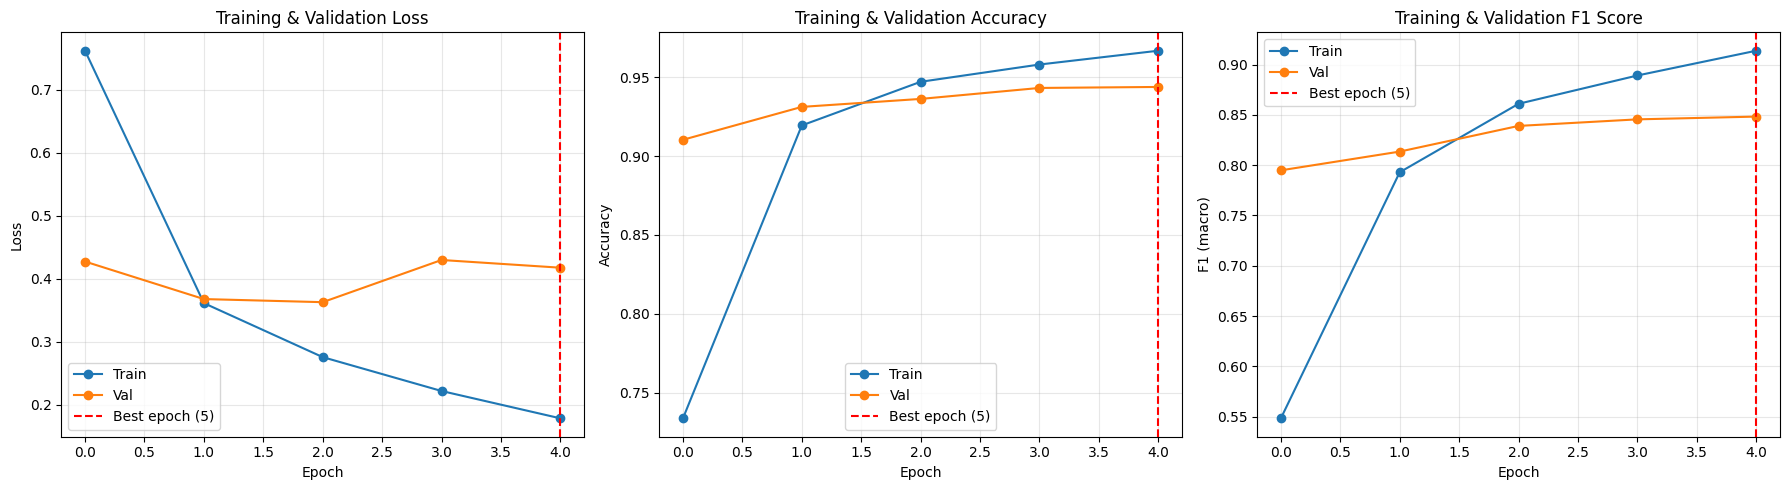

Saved: training_history.png


In [17]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='o')
axes[0].axvline(best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'], label='Val', marker='o')
axes[1].axvline(best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(history['train_f1'], label='Train', marker='o')
axes[2].plot(history['val_f1'], label='Val', marker='o')
axes[2].axvline(best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 (macro)')
axes[2].set_title('Training & Validation F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_history.png')

## 9. Test Evaluation

In [18]:
# Load best model
model.load_state_dict(torch.load(os.path.join(config.MODELS_DIR, 'best_model.pt')))
print('Loaded best model!')

# Evaluate on test set
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, config.DEVICE
)

print('\n' + '='*60)
print('TEST RESULTS')
print('='*60)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1 (macro): {test_f1:.4f}')

Loaded best model!


Evaluating: 100%|██████████| 99/99 [00:41<00:00,  2.37it/s]


TEST RESULTS
Test Loss: 0.5137
Test Accuracy: 0.9274
Test F1 (macro): 0.8136


In [19]:
# Classification report
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=list(config.LABEL_MAP.values())))

report = classification_report(
    test_labels, test_preds,
    target_names=list(config.LABEL_MAP.values()),
    output_dict=True
)


Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95      1409
     Neutral       0.59      0.51      0.55       167
    Positive       0.95      0.95      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.83      0.80      0.81      3166
weighted avg       0.92      0.93      0.93      3166



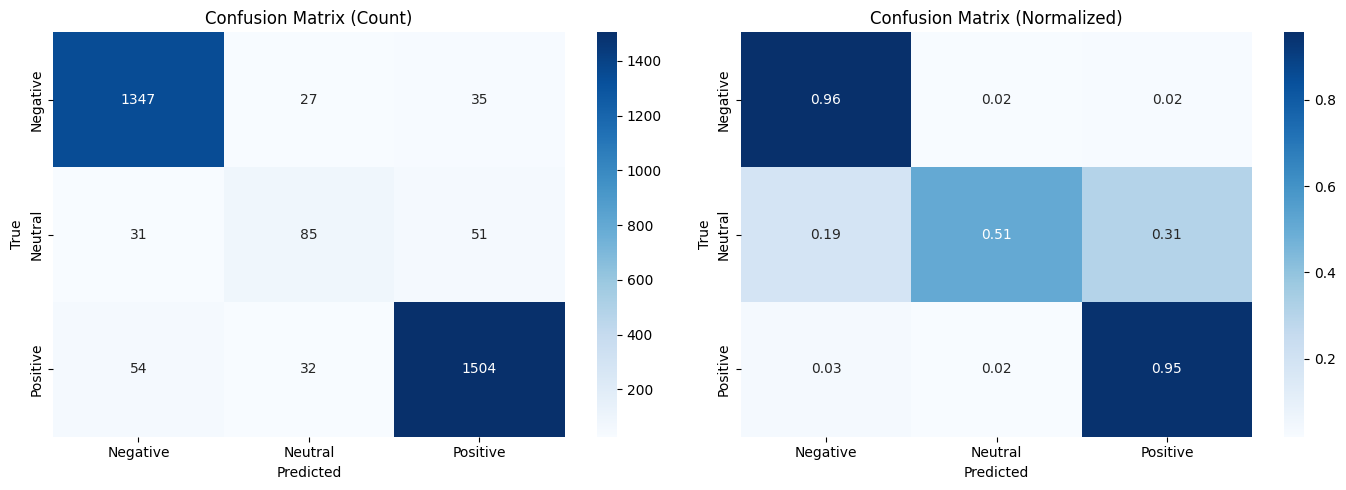

Saved: confusion_matrix.png


In [20]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            xticklabels=list(config.LABEL_MAP.values()),
            yticklabels=list(config.LABEL_MAP.values()),
            cmap='Blues')
axes[0].set_title('Confusion Matrix (Count)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=axes[1],
            xticklabels=list(config.LABEL_MAP.values()),
            yticklabels=list(config.LABEL_MAP.values()),
            cmap='Blues')
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

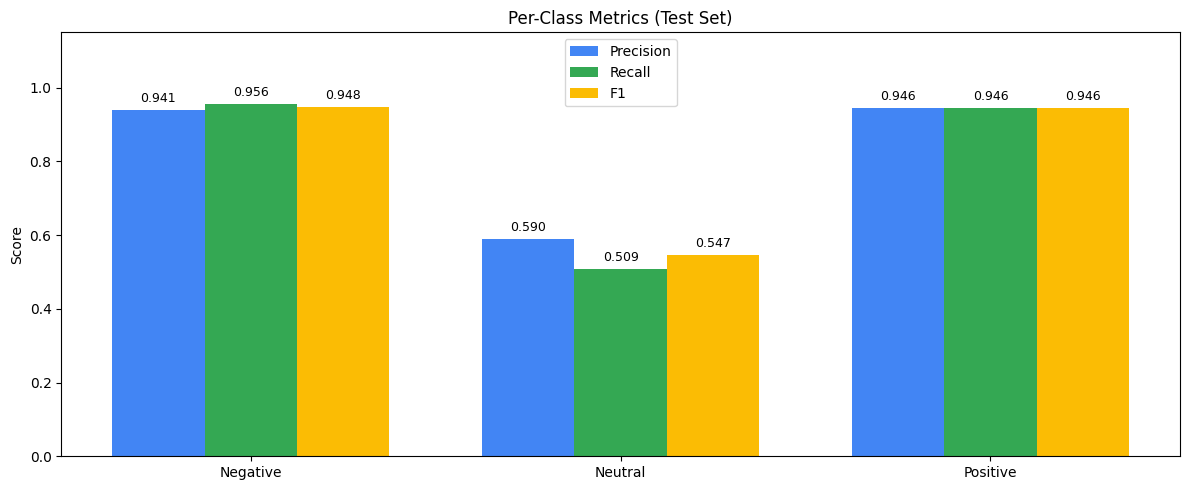

Saved: per_class_metrics.png


In [21]:
# Per-class metrics
prec, rec, f1, _ = precision_recall_fscore_support(test_labels, test_preds, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(config.LABEL_MAP))
width = 0.25

ax.bar(x - width, prec, width, label='Precision', color='#4285F4')
ax.bar(x, rec, width, label='Recall', color='#34A853')
ax.bar(x + width, f1, width, label='F1', color='#FBBC04')

ax.set_xticks(x)
ax.set_xticklabels(list(config.LABEL_MAP.values()))
ax.set_ylabel('Score')
ax.set_title('Per-Class Metrics (Test Set)')
ax.legend()
ax.set_ylim(0, 1.15)

for i, (p, r, f) in enumerate(zip(prec, rec, f1)):
    ax.text(i - width, p + 0.02, f'{p:.3f}', ha='center', fontsize=9)
    ax.text(i, r + 0.02, f'{r:.3f}', ha='center', fontsize=9)
    ax.text(i + width, f + 0.02, f'{f:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_metrics.png')

## 10. Save Results

In [22]:
# Save training results
lines = [
    '=' * 50,
    'TRAINING RESULTS - PhoBERT + SentiWordNet (Fine-tuned)',
    '=' * 50,
    f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    'Model Type: PhoBERT_Sentiwordnet',
    'Experiment: improvements/20260316 (End-to-End)',
    '',
    '-' * 50,
    'MODEL ARCHITECTURE',
    '-' * 50,
    f'PhoBERT: {config.MODEL_NAME} (UNFROZEN - trainable)',
    'SentiWordNet Features: 35 (extended)',
    'Feature Projection: 35 -> 64',
    'Combined: 768 + 64 = 832',
    'Classifier: 832 -> 256 -> 3',
    '',
    '-' * 50,
    'HYPERPARAMETERS',
    '-' * 50,
    f'Learning Rate: {config.LEARNING_RATE}',
    f'Batch Size: {config.BATCH_SIZE}',
    f'Max Length: {config.MAX_LENGTH}',
    f'Epochs: {config.EPOCHS}',
    f'Warmup Ratio: {config.WARMUP_RATIO}',
    f'Weight Decay: {config.WEIGHT_DECAY}',
    f'Dropout: {config.DROPOUT}',
    f'Early Stop Patience: {config.EARLY_STOP_PATIENCE}',
    f'Class Weights: {config.CLASS_WEIGHTS.tolist()}',
    f'Gradient Clip: {config.GRADIENT_CLIP}',
    '',
    '-' * 50,
    'TRAINING HISTORY',
    '-' * 50,
    f'Total Epochs Trained: {len(history["train_loss"])}',
    f'Best Epoch: {best_epoch}',
    f'Best Val F1: {best_val_f1:.4f}',
    '',
    '-' * 50,
    'TEST RESULTS',
    '-' * 50,
    f'Test Accuracy: {test_acc:.4f}',
    f'Test F1 (macro): {test_f1:.4f}',
    '',
    'Per-Class Metrics:',
    f'  Negative: P={report["Negative"]["precision"]:.4f}, R={report["Negative"]["recall"]:.4f}, F1={report["Negative"]["f1-score"]:.4f}',
    f'  Neutral:  P={report["Neutral"]["precision"]:.4f}, R={report["Neutral"]["recall"]:.4f}, F1={report["Neutral"]["f1-score"]:.4f}',
    f'  Positive: P={report["Positive"]["precision"]:.4f}, R={report["Positive"]["recall"]:.4f}, F1={report["Positive"]["f1-score"]:.4f}',
    '',
    '-' * 50,
    'CONFUSION MATRIX (Test)',
    '-' * 50,
]

for row in cm:
    lines.append(f'[{row[0]:4d} {row[1]:4d} {row[2]:4d}]')

training_results_path = os.path.join(config.SUMMARIES_DIR, 'training_results.txt')
with open(training_results_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print('Saved: training_results.txt')

Saved: training_results.txt


In [23]:
# Save experiment summary JSON
summary = {
    'Model': 'PhoBERT + SentiWordNet (Fine-tuned)',
    'Date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Test Accuracy': float(test_acc),
    'Test F1 (macro)': float(test_f1),
    'Best Epoch': best_epoch,
    'Total Epochs': len(history['train_loss']),
    'Hyperparameters': {
        'Learning Rate': config.LEARNING_RATE,
        'Batch Size': config.BATCH_SIZE,
        'Max Length': config.MAX_LENGTH,
        'Dropout': config.DROPOUT,
        'Class Weights': config.CLASS_WEIGHTS.tolist()
    },
    'Features': {
        'PhoBERT': '768-dim (trainable)',
        'SentiWordNet': '35 features (extended)',
        'Architecture': '768 + 64 -> 256 -> 3'
    },
    'Per-Class F1': {
        'Negative': float(report['Negative']['f1-score']),
        'Neutral': float(report['Neutral']['f1-score']),
        'Positive': float(report['Positive']['f1-score'])
    }
}

with open(os.path.join(config.SUMMARIES_DIR, 'experiment_summary.json'), 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('Saved: experiment_summary.json')

Saved: experiment_summary.json


In [24]:
# Save training history
history_df = {
    'epoch': list(range(1, len(history['train_loss']) + 1)),
    'train_loss': history['train_loss'],
    'train_acc': history['train_acc'],
    'train_f1': history['train_f1'],
    'val_loss': history['val_loss'],
    'val_acc': history['val_acc'],
    'val_f1': history['val_f1']
}

pd.DataFrame(history_df).to_csv(os.path.join(config.SUMMARIES_DIR, 'training_history.csv'), index=False)
print('Saved: training_history.csv')

Saved: training_history.csv


## 11. Final Summary

In [25]:
print('\n' + '=' * 60)
print('PHOBERT + SENTIWORDNET (FINE-TUNED) - FINAL SUMMARY')
print('=' * 60)

print('\nModel Architecture:')
print('  - PhoBERT: 768-dim (UNFROZEN - trainable)')
print('  - SentiWordNet: 35 features -> 64-dim projection')
print('  - Combined: 768 + 64 = 832 features')
print('  - Classifier: 832 -> 256 -> 3 classes')

print(f'\nTraining:')
print(f'  - Best epoch: {best_epoch}')
print(f'  - Best validation F1: {best_val_f1:.4f}')

print(f'\nTest Results:')
print(f'  - Accuracy: {test_acc:.4f}')
print(f'  - F1 (macro): {test_f1:.4f}')

print('\nPer-Class F1 Scores:')
for cls_name in config.LABEL_MAP.values():
    print(f'  - {cls_name}: {report[cls_name]["f1-score"]:.4f}')

print('\nFiles saved:')
print(f'  - Model: {config.MODELS_DIR}/best_model.pt')
print(f'  - Summary: {config.SUMMARIES_DIR}/')
print(f'  - Visualizations: {config.VISUALIZATIONS_DIR}/')
print(f'  - Artifacts: {config.ARTIFACTS_DIR}/')

print('\n' + '=' * 60)


PHOBERT + SENTIWORDNET (FINE-TUNED) - FINAL SUMMARY

Model Architecture:
  - PhoBERT: 768-dim (UNFROZEN - trainable)
  - SentiWordNet: 35 features -> 64-dim projection
  - Combined: 768 + 64 = 832 features
  - Classifier: 832 -> 256 -> 3 classes

Training:
  - Best epoch: 5
  - Best validation F1: 0.8483

Test Results:
  - Accuracy: 0.9274
  - F1 (macro): 0.8136

Per-Class F1 Scores:
  - Negative: 0.9483
  - Neutral: 0.5466
  - Positive: 0.9459

Files saved:
  - Model: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/improvements/20260316/models/best_model.pt
  - Summary: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/improvements/20260316/summaries/
  - Visualizations: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/improvements/20260316/visualizations/
  - Artifacts: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet/improvement